# Auditoría de Calidad — Defunciones Generales Ecuador 2021

## Proyecto 0.2 | EDA desde Cero con Datos Sucios

**Fuente:** Registro Estadístico de Defunciones Generales 2021 — INEC Ecuador  
**Registros:** 107,648 × 45 columnas  
**Objetivo:** Diagnosticar el estado real del dataset antes de limpiarlo. Documentar cada problema de calidad encontrado con evidencia.

---

### ¿Para qué sirve este notebook?

Este, en primer lugar, será el **diagnóstico**, no el tratamiento. Aquí respondemos a las cuestiones:
1. ¿Qué forma tienen los datos? (filas, columnas, tipos)
2. ¿Dónde hay valores faltantes y cuántos?
3. ¿Hay duplicados?
4. ¿Qué inconsistencias de formato existen?
5. ¿Qué problemas de calidad documentamos para resolver en el Notebook 02?

> *Analogía matemática: esto es como verificar las hipótesis de un teorema antes de intentar su demostración. Si los datos no cumplen ciertas condiciones, cualquier análisis posterior es inválido.*

## 1. Imports y configuración

Procedemos a cargar las librerías necesarias para la auditoría:
- **pandas** — cargar y explorar el dataset
- **numpy** — operaciones numéricas (detección de outliers)
- **matplotlib / seaborn** — visualizaciones
- **missingno** — mapa visual de valores nulos
- **sqlite3** — viene con Python, lo usaremos en el Notebook 03

In [3]:
# =\= IMPORTS =\=
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

# =\= CONFIGURACIÓN =\=
# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Mostrar todas las columnas en DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 50)

# Ruta a los datos (relativa — nunca absoluta)
RAW_PATH = Path('../data/raw/')

print("Imports y configuración listos")

Imports y configuración listos


## 2. Carga del dataset

Cargamos el CSV con dos configuraciones importantes:
- **Separador:** punto y coma (`;`), estándar en archivos gubernamentales
- **Encoding:** UTF-8 (es el estándar de codificación de caracteres dominante en la web, diseñado para representar prácticamente cualquier carácter de cualquier idioma, además de emojis, utilizando entre 1 y 4 bytes), verificaremos si hay caracteres mal decodificados

In [4]:
# Cargar el dataset
df = pd.read_csv(RAW_PATH / 'EDG_2021_act_CSV.csv', sep=';')

# Primera verificación: dimensiones del dataset
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

C:\Users\Eduardo Araque\AppData\Local\Temp\ipykernel_12500\4272201579.py:2: DtypeWarning: Columns (0: anio_nac, 1: dia_nac, 2: edad) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_PATH / 'EDG_2021_act_CSV.csv', sep=';')


Dimensiones: 107,648 filas × 45 columnas


In [45]:
# Como vimos, nos aparece un error, vamos a recargar con low_memory=False para evitar la advertencia de que hay columnas que tienen tipos mezclados
df = pd.read_csv(RAW_PATH / 'EDG_2021_act_CSV.csv', sep=';', low_memory=False)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n Primer problema detectado:")
print(f"   Columnas con tipos mixtos: anio_nac, dia_nac, edad")
print(f"   Esto indica la existencia de valores no numéricos donde debería haber números.")

Dimensiones: 107,648 filas × 45 columnas

 Primer problema detectado:
   Columnas con tipos mixtos: anio_nac, dia_nac, edad
   Esto indica la existencia de valores no numéricos donde debería haber números.


## 3. Primera inspección

### 3.1 Tipos de datos y memoria

`df.info()` es el equivalente a "abrir el expediente del paciente". Nos dice:
- El nombre de cada columna
- Cuántos valores **no nulos** tiene (si es menor que 107,648 → hay nulos)
- El tipo de dato que Pandas asignó automáticamente

> *Si una columna que debería ser numérica aparece como `object` (texto), es señal de problemas de calidad.*

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107648 entries, 0 to 107647
Data columns (total 45 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Numeracion  107648 non-null  int64
 1   prov_insc   107648 non-null  str  
 2   cant_insc   107648 non-null  str  
 3   parr_insc   107648 non-null  str  
 4   anio_insc   107648 non-null  str  
 5   mes_insc    107648 non-null  str  
 6   dia_insc    107648 non-null  str  
 7   fecha_insc  107648 non-null  str  
 8   nac_fall    107648 non-null  str  
 9   cod_pais    107648 non-null  str  
 10  sexo        107648 non-null  str  
 11  anio_nac    107648 non-null  str  
 12  mes_nac     107648 non-null  str  
 13  dia_nac     107648 non-null  str  
 14  fecha_nac   107648 non-null  str  
 15  anio_fall   107648 non-null  int64
 16  mes_fall    107648 non-null  str  
 17  dia_fall    107648 non-null  int64
 18  fecha_fall  107648 non-null  str  
 19  cod_edad    107648 non-null  str  
 20  edad        107

### 3.2 Nulos disfrazados

`df.info()` reporta 0 valores nulos en todas las columnas. Pero veamos porqué eso es engañoso.

En datos gubernamentales, los valores faltantes rara vez aparecen como celdas vacías. En su lugar, se registran como:
- Espacios en blanco (`" "`)
- Texto como `"Sin información"`, `"No aplica"`, `"Ignorado"`
- Valores numéricos imposibles (99, 999, 0 donde no tiene sentido)

Así que necesitamos buscar estos patrones para conocer el estado real del dataset.

In [47]:
# Vamos a buscar valores sospechosos de ser "nulos disfrazados"
# Primero: ¿qué valores únicos cortos o vacíos hay? (debíamos haberle echado un ojo al dataset antes)
sospechosos = []

for col in df.columns:
    # Obtener valores únicos que sean strings cortos o vacíos
    if df[col].dtype == 'object' or df[col].dtype.name == 'str':
        unicos = df[col].unique()
        for val in unicos:
            if isinstance(val, str):
                val_limpio = val.strip().lower()
                if val_limpio in ['', ' ', 'sin información', 'sin informacion',
                                   'no aplica', 'ignorado', 'no informa',
                                   'se ignora', 'sin dato', 'nd', 'n/a',
                                   'no disponible', 'no especificado']:
                    sospechosos.append({
                        'columna': col,
                        'valor_encontrado': repr(val),
                        'frecuencia': int((df[col] == val).sum())
                    })

# Mostrar como tabla
df_sospechosos = pd.DataFrame(sospechosos)
if len(df_sospechosos) > 0:
    df_sospechosos = df_sospechosos.sort_values('frecuencia', ascending=False)
    print(f" Se encontraron {len(df_sospechosos)} patrones de nulos disfrazados:\n")
    display(df_sospechosos.to_string(index=False))
else:
    print("No se encontraron patrones sospechosos (poco probable — revisar manualmente)")

 Se encontraron 30 patrones de nulos disfrazados:



"   columna  valor_encontrado  frecuencia\nmuj_fertil               ' '      102024\n  lug_viol               ' '       98255\n  mor_viol               ' '       98255\n  autopsia 'Sin información'       31137\n sabe_leer 'Sin información'        6448\n  niv_inst 'Sin información'        4963\n     etnia 'Sin información'        4548\n  autopsia               ' '        3996\nmuj_fertil 'Sin información'        2979\n est_civil 'Sin información'        2963\n  lug_viol 'Sin información'        1599\n sabe_leer               ' '        1594\n  niv_inst               ' '        1594\n cant_insc               ' '        1057\n prov_insc               ' '        1057\nfecha_insc               ' '        1057\n  dia_insc               ' '        1057\n  mes_insc               ' '        1057\n anio_insc               ' '        1057\n parr_insc               ' '        1057\nlugar_ocur 'Sin información'         346\n   cer_por 'Sin información'         345\n  nac_fall 'Sin información'     

### 3.3 Análisis de los nulos disfrazados

El dataset reportaba **0 valores nulos**, pero vemos que encontramos **30 patrones** de valores faltantes disfrazados en dos formas principales:

- **Espacios en blanco (`' '`)** — la celda parece vacía pero tiene un espacio
- **`'Sin información'`** — texto explícito que indica dato faltante
- **`'No aplica'`** — valor que indica que la variable no corresponde para ese registro

Visualicemos cuáles son los más graves por volumen:

In [36]:
# Agrupar nulos disfrazados por columna
nulos_por_columna = df_sospechosos.groupby('columna')['frecuencia'].sum().sort_values(ascending=False)

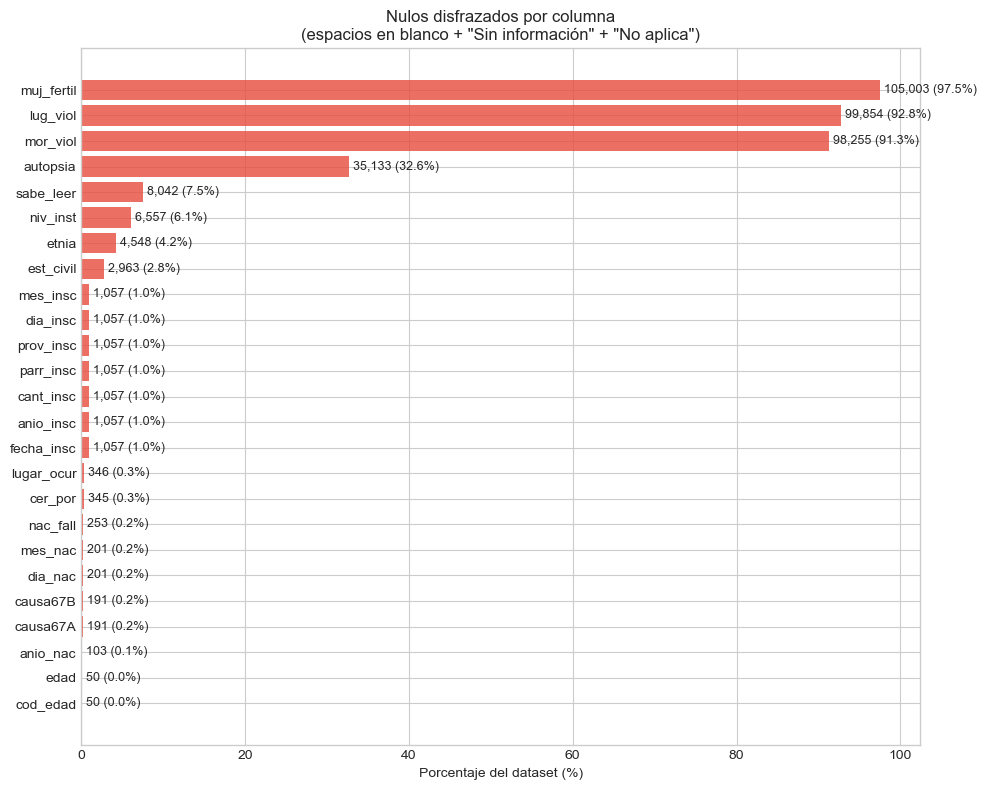

In [37]:
# Gráfico de barras horizontal de los nulos disfrazados por columna
fig, ax = plt.subplots(figsize=(10, 8))

columnas = nulos_por_columna.index
valores = nulos_por_columna.values
porcentajes = valores / len(df) * 100

bars = ax.barh(columnas, porcentajes, color='#e74c3c', alpha=0.8)

# Agregar el porcentaje al final de cada barra
for bar, val, pct in zip(bars, valores, porcentajes):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Porcentaje del dataset (%)')
ax.set_title('Nulos disfrazados por columna\n(espacios en blanco + "Sin información" + "No aplica")')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/01_nulos_disfrazados.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Vista previa de los datos

Veamos las primeras y últimas filas para detectar patrones visualmente.

In [20]:
# Primeras 5 filas
df.head()

,Numeracion,prov_insc,cant_insc,parr_insc,anio_insc,mes_insc,dia_insc,fecha_insc,nac_fall,cod_pais,sexo,anio_nac,mes_nac,dia_nac,fecha_nac,anio_fall,mes_fall,dia_fall,fecha_fall,cod_edad,edad,prov_res,sabe_leer,etnia,lugar_ocur,prov_fall,cant_fall,parr_fall,muj_fertil,mor_viol,lug_viol,autopsia,causa4,cer_por,area_fall,area_res,est_civil,niv_inst,residente,causa,causa103,causa80,causa67A,causa67B,lc1
0,102195,Pichincha,Quito,Iñaquito,2021,Diciembre,31,2021-12-31,Extranjero,Bolivia (Estado Plurinacional de),Hombre,1945,Julio,28,1945-07-28,2021,Diciembre,29,2021-12-29,Años,76,Pichincha,Si,Mestizo (a),Casa,Pichincha,Quito,Cumbaya,,,,Sin información,I10 Hipertensión esencial (primaria),Médico no tratante,Rural,Rural,Casado (a),Superior universitario,Residente,I10 Hipertensión esencial (primaria),066 Enfermedades hipertensivas,052 Enfermedades hipertensivas,030 Enfermedades del sistema circulatorio,030 Enfermedades del sistema circulatorio,34 Enfermedades hipertensivas
1,60826,Guayas,Guayaquil,Rocafuerte,2021,Febrero,18,2021-02-18,Extranjero,Bélgica,Mujer,1923,Mayo,24,1923-05-24,2021,Febrero,18,2021-02-18,Años,97,Guayas,Si,Blanco (a),Casa,Guayas,Guayaquil,Tarqui,,,,Sin información,"I219 Infarto agudo del miocardio, sin otra es...",Médico tratante,Urbano,Urbano,Soltero (a),Secundaria,Residente,I21 Infarto agudo del miocardio,067 Enfermedades isquémicas del corazón,053 Enfermedades isquémicas del corazón,030 Enfermedades del sistema circulatorio,030 Enfermedades del sistema circulatorio,35 Enfermedades isquémicas del corazón
2,74553,Esmeraldas,Esmeraldas,Esmeraldas,2021,Enero,28,2021-01-28,Extranjero,Colombia,Hombre,1948,Abril,4,1948-04-04,2020,Diciembre,21,2020-12-21,Años,72,Esmeraldas,Si,Mestizo (a),Establecimientos del Ministerio de Salud,Esmeraldas,Esmeraldas,Esmeraldas,,,,No,"COVID-19, virus no identificado",Médico no tratante,Urbano,Urbano,Soltero (a),Primaria,Residente,U07 COVID-19 Confirmados y sospechosos,104 COVID-19,081 COVID 19,"U072 COVID-19, Virus no identificado",068 COVID 19,"COVID-19, virus no identificado"
3,19836,Napo,El Chaco,El Chaco,2021,Mayo,07,2021-05-07,Extranjero,Colombia,Hombre,1933,Abril,28,1933-04-28,2021,Mayo,6,2021-05-06,Años,88,Napo,Sin información,Sin información,Casa,Napo,Quijos,Cosanga,,,,,R98 Muerte sin asistencia,Funcionario de Registro Civil,Rural,Rural,Viudo (a),Sin información,Residente,R98 Muerte sin asistencia,"094 Sintomas, signos y hallazgos anormales cl...","071 Sintoms,signs y hallz anorm cli.y d.lab, n...","056 Síntomas, signos y hallazgos anormales","058 Otros síntomas, signos y hallazgos anormal...",99 Causas mal definidas
4,53244,Pichincha,Quito,San Juan,2021,Noviembre,16,2021-11-16,Extranjero,Zonas sin especificar,Hombre,1944,Marzo,27,1944-03-27,2021,Noviembre,15,2021-11-15,Años,77,Pichincha,Si,Mestizo (a),Casa,Pichincha,Rumiñahui,Sangolquí,,,,Sin información,"G809 Parálisis cerebral, sin otra especificación",Médico no tratante,Urbano,Urbano,Divorciado (a),Educación Básica,Residente,G80 Parálisis cerebral,061 Resto de enfermedades del sistema nervioso,072 Todas las demas enfermedades,026 Enfermedades del sistema nervioso,028 Resto de enfermedades del sistema nervioso,88 Resto de causas


### 3.5 Estadísticas descriptivas de las columnas numéricas

`describe()` sobre las columnas que Pandas reconoció como numéricas.
Solo hay 3: `Numeracion`, `anio_fall` y `dia_fall`.

In [22]:
df.describe()

,Numeracion,anio_fall,dia_fall
count,107648.000000,107648.000000,107648.000000
mean,53824.500000,2020.856653,15.708076
std,31075.445226,2.219367,8.753548
min,1.000000,1900.000000,1.000000
25%,26912.750000,2021.000000,8.000000
50%,53824.500000,2021.000000,16.000000
75%,80736.250000,2021.000000,23.000000
max,107648.000000,2021.000000,31.000000


### 3.6 Valores sospechosos en columnas numéricas

El año de fallecimiento tiene un mínimo de **1900** en un dataset de 2021.
¿Cuántos registros hay fuera de rango?

In [24]:
# ¿Cuántos registros tienen anio_fall diferente de 2021?
fuera_de_2021 = df[df['anio_fall'] != 2021]
print(f"Registros con año de fallecimiento distinto al 2021: {len(fuera_de_2021):,}")
print(f"\nDistribución de años fuera de 2021:")
print(fuera_de_2021['anio_fall'].value_counts().sort_index())

Registros con año de fallecimiento distinto al 2021: 2,400

Distribución de años fuera de 2021:
anio_fall
1900       1
1903       1
1918       1
1922       1
1924       1
1938       1
1939       1
1940       1
1941       1
1945       3
1948       1
1950       5
1952       3
1953       2
1954       1
1955       2
1958       1
1959       1
1960       1
1962       2
1963       1
1964       3
1965       4
1966       3
1967       1
1968       7
1969       2
1970       5
1971       2
1972       6
1973       6
1974       9
1975       9
1976       1
1977       5
1978       1
1979       5
1980       4
1981       6
1982       5
1983       5
1984       3
1985      10
1987       7
1988       4
1989       6
1990       6
1991       5
1992       9
1993       8
1994       5
1995      11
1996       8
1997       7
1998      13
1999      10
2000       9
2001      11
2002      17
2003      12
2004      19
2005      14
2006      15
2007      20
2008      20
2009      13
2010      11
2011      11
2012      

### 3.7 Exploración de columnas categóricas

Las 42 columnas de tipo texto (`str`) son categóricas. Veamos cuántos valores
únicos tiene cada una para entender su naturaleza: ¿es una variable con pocas
categorías (como `sexo`) o muchas (como `parr_fall`)?

In [43]:
# Valores únicos por columna (solo las de tipo texto/string)
cols_texto = df.select_dtypes(include='str').columns

resumen = []
for col in cols_texto:
    n_unicos = df[col].nunique()
    ejemplo = df[col].value_counts().index[0]  # el valor más frecuente
    resumen.append({
        'columna': col,
        'valores_unicos': n_unicos,
        'valor_mas_frecuente': ejemplo
    })

df_resumen = pd.DataFrame(resumen).sort_values('valores_unicos', ascending=False)
display(df_resumen)

,columna,valores_unicos,valor_mas_frecuente
13,fecha_nac,29641,9999-99-99
29,causa4,2348,"COVID-19, virus identificado"
15,fecha_fall,1386,2021-04-21
24,parr_fall,1106,Tarqui
36,causa,881,U07 COVID-19 Confirmados y sospechosos
6,fecha_insc,434,
23,cant_fall,220,Guayaquil
2,parr_insc,207,Rocafuerte
1,cant_insc,168,Guayaquil
10,anio_nac,139,1936


### 3.8 Nuevo patrón de nulos: fechas imposibles

La exploración reveló que `fecha_nac` tiene como valor más frecuente `9999-99-99`.
Este es un patrón de nulo disfrazado que no habíamos detectado: en lugar de dejar
el campo vacío, se usa una fecha imposible como marcador.

¿Cuántos registros tienen este patrón?

In [26]:
# Contar fechas imposibles
fechas_99 = (df['fecha_nac'] == '9999-99-99').sum()
print(f"Registros con fecha_nac = '9999-99-99': {fechas_99:,} ({fechas_99/len(df)*100:.1f}%)")

# ¿Hay otras fechas imposibles en las demás columnas de fecha?
for col in ['fecha_nac', 'fecha_fall', 'fecha_insc']:
    tiene_99 = df[col].str.contains('9999|99-99', na=False).sum()
    print(f"{col}: {tiene_99:,} fechas con patrón '9999' o '99-99'")

Registros con fecha_nac = '9999-99-99': 103 (0.1%)
fecha_nac: 201 fechas con patrón '9999' o '99-99'
fecha_fall: 0 fechas con patrón '9999' o '99-99'
fecha_insc: 0 fechas con patrón '9999' o '99-99'


In [27]:
# Ver los diferentes patrones de fechas imposibles en fecha_nac
fechas_raras = df[df['fecha_nac'].str.contains('99-99', na=False)]['fecha_nac'].value_counts().head(10)
print("Patrones de fechas imposibles en fecha_nac:\n")
print(fechas_raras)

Patrones de fechas imposibles en fecha_nac:

fecha_nac
9999-99-99    103
1980-99-99     26
2000-99-99     10
1991-99-99      4
1982-99-99      3
1986-99-99      3
1966-99-99      3
1931-99-99      2
1959-99-99      2
1894-99-99      2
Name: count, dtype: int64


### 3.9 Inconsistencias de formato: mayúsculas, minúsculas y espacios

Verificamos si hay valores que parecen distintos pero son el mismo dato
escrito de forma diferente (ej: "QUITO" vs "Quito" vs "quito").

In [41]:
# Verificar inconsistencias en columnas geográficas y categóricas clave
cols_verificar = ['prov_insc', 'cant_insc', 'prov_fall', 'cant_fall', 
                  'sexo', 'etnia', 'est_civil', 'niv_inst']

for col in cols_verificar:
    valores = df[col].str.strip().unique()
    valores_lower = df[col].str.strip().str.lower().unique()
    if len(valores) != len(valores_lower):
        print(f" {col}: {len(valores)} valores únicos → {len(valores_lower)} al normalizar")
    else:
        print(f"{col}: No presenta inconsistencias de mayúsculas/minúsculas")

prov_insc: No presenta inconsistencias de mayúsculas/minúsculas
cant_insc: No presenta inconsistencias de mayúsculas/minúsculas
prov_fall: No presenta inconsistencias de mayúsculas/minúsculas
cant_fall: No presenta inconsistencias de mayúsculas/minúsculas
sexo: No presenta inconsistencias de mayúsculas/minúsculas
etnia: No presenta inconsistencias de mayúsculas/minúsculas
est_civil: No presenta inconsistencias de mayúsculas/minúsculas
niv_inst: No presenta inconsistencias de mayúsculas/minúsculas


## 4. Tabla de auditoría. Resumen de problemas de calidad

Esta tabla consolida todos los problemas que hemos detectado. Cada problema tendrá
una decisión de tratamiento en el Notebook 02 (pipeline de limpieza).

In [44]:
# Tabla de auditoría consolidada
auditoria = pd.DataFrame({
    'problema': [
        'Nulos disfrazados: espacios en blanco',
        'Nulos disfrazados: "Sin información"',
        'Nulos disfrazados: "No aplica"',
        'Fechas imposibles: 9999-99-99',
        'Fechas parciales: año-99-99',
        'Tipos mixtos: columnas numéricas como texto',
        'Registros de años anteriores a 2021',
        'Código + descripción pegados en columna causa',
    ],
    'columnas_afectadas': [
        'muj_fertil, lug_viol, mor_viol, autopsia, sabe_leer, niv_inst, y 10 más',
        'autopsia, sabe_leer, niv_inst, etnia, est_civil, muj_fertil, y 6 más',
        'causa67A, causa67B',
        'fecha_nac',
        'fecha_nac',
        'anio_nac, dia_nac, edad',
        'anio_fall (2,400 registros de 1900-2020)',
        'causa4, causa, causa103, causa80, causa67A, causa67B',
    ],
    'registros_afectados': [
        '~308,000 celdas en total',
        '~55,000 celdas en total',
        '382 celdas',
        '103',
        '98',
        '107,648 (toda la columna está como texto)',
        '2,400',
        '107,648 (diseño del dataset)',
    ],
    'severidad': [
        'Alta',
        'Alta',
        'Baja',
        'Media',
        'Media',
        'Alta',
        'Media',
        'Media',
    ]
})

display(auditoria)

,problema,columnas_afectadas,registros_afectados,severidad
0,Nulos disfrazados: espacios en blanco,"muj_fertil, lug_viol, mor_viol, autopsia, sabe_leer, niv_inst, y 10 más","~308,000 celdas en total",Alta
1,"Nulos disfrazados: ""Sin información""","autopsia, sabe_leer, niv_inst, etnia, est_civil, muj_fertil, y 6 más","~55,000 celdas en total",Alta
2,"Nulos disfrazados: ""No aplica""","causa67A, causa67B",382 celdas,Baja
3,Fechas imposibles: 9999-99-99,fecha_nac,103,Media
4,Fechas parciales: año-99-99,fecha_nac,98,Media
5,Tipos mixtos: columnas numéricas como texto,"anio_nac, dia_nac, edad","107,648 (toda la columna está como texto)",Alta
6,Registros de años anteriores a 2021,"anio_fall (2,400 registros de 1900-2020)","2,400",Media
7,Código + descripción pegados en columna causa,"causa4, causa, causa103, causa80, causa67A, causa67B","107,648 (diseño del dataset)",Media


## 5. Detección de duplicados

Buscamos **duplicados exactos** (filas idénticas en todas las columnas). 
Los **duplicados semánticos** (mismo registro con formato diferente) se abordarán
en el Notebook 02 después de normalizar el formato de las columnas de texto. 

In [30]:
# Duplicados exactos (todas las columnas iguales)
dupes_exactos = df.duplicated().sum()
print(f"Duplicados exactos: {dupes_exactos:,}")

# Duplicados sin contar Numeración (que es un ID único)
dupes_sin_id = df.drop(columns='Numeracion').duplicated().sum()
print(f"Duplicados ignorando Numeracion: {dupes_sin_id:,}")

Duplicados exactos: 0
Duplicados ignorando Numeracion: 7


In [32]:
# Ver los duplicados ignorando Numeración
mascara = df.drop(columns='Numeracion').duplicated(keep=False)
dupes = df[mascara].sort_values(by=['fecha_fall', 'prov_fall'])

# Mostrar solo algunas de las columnas más relevantes para comparar
cols_ver = ['Numeracion', 'sexo', 'fecha_nac', 'fecha_fall', 'edad',
            'prov_fall', 'cant_fall', 'causa4']
display(dupes[cols_ver])

,Numeracion,sexo,fecha_nac,fecha_fall,edad,prov_fall,cant_fall,causa4
71434,69189,Hombre,9999-99-99,2016-05-20,Sin información,Manabí,Montecristi,"Y249 Disparo de otras armas de fuego, y las n..."
71442,69188,Hombre,9999-99-99,2016-05-20,Sin información,Manabí,Montecristi,"Y249 Disparo de otras armas de fuego, y las n..."
27059,111,Mujer,2021-01-01,2021-01-04,3,Manabí,Portoviejo,P229 Dificultad respiratoria del recién nacid...
62783,112,Mujer,2021-01-01,2021-01-04,3,Manabí,Portoviejo,P229 Dificultad respiratoria del recién nacid...
71338,8320,Mujer,2021-02-03,2021-02-03,0,Santo Domingo de los Tsáchilas,Santo Domingo,P072 Inmaturidad extrema
71339,8319,Mujer,2021-02-03,2021-02-03,0,Santo Domingo de los Tsáchilas,Santo Domingo,P072 Inmaturidad extrema
37648,68270,Hombre,2018-11-05,2021-03-20,2,Azuay,Sigsig,W730 Otros ahogamientos y sumersiones especif...
73747,68269,Hombre,2018-11-05,2021-03-20,2,Azuay,Sigsig,W730 Otros ahogamientos y sumersiones especif...
22816,61535,Mujer,2021-04-18,2021-04-18,0,Los Ríos,Babahoyo,P009 Feto y recién nacido afectados por afecc...
94888,61536,Mujer,2021-04-18,2021-04-18,0,Los Ríos,Babahoyo,P009 Feto y recién nacido afectados por afecc...


### 5.1 Conclusión sobre los duplicados

Se encontraron **7 pares de registros duplicados** (14 filas). Características:
- IDs consecutivos, ingresados uno tras otro en el sistema
- Datos idénticos en las 44 columnas restantes
- Mayoría son defunciones neonatales (recién nacidos)
- Probable causa: doble inscripción por hospital y registro civil

**Decisión para el Notebook 02:** eliminar el duplicado con ID mayor de cada par
(conservar el primer registro que se tuvo).

## 6. Mapa visual de nulos

Para hacernos una idea visual de los patrones de nulos, primero convertimos los nulos disfrazados
a `NaN` reales (solo en una copia temporal, no vamos a modificar el dataset original).
La librería `missingno` genera una matriz visual donde cada fila es un registro
y cada columna es una variable: blanco = dato faltante, color = dato presente.

In [33]:
# Copia temporal con nulos reales para visualización
df_temp = df.copy()

# Convertir espacios en blanco a NaN
for col in df_temp.columns:
    if df_temp[col].dtype == 'object' or df_temp[col].dtype.name == 'str':
        df_temp[col] = df_temp[col].replace(r'^\s*$', np.nan, regex=True)

# Convertir "Sin información" y "No aplica" a NaN
df_temp = df_temp.replace('Sin información', np.nan)
df_temp = df_temp.replace('No aplica', np.nan)

# Convertir fechas imposibles a NaN
df_temp['fecha_nac'] = df_temp['fecha_nac'].replace('9999-99-99', np.nan)
df_temp.loc[df_temp['fecha_nac'].str.contains('99-99', na=False), 'fecha_nac'] = np.nan

# Verificar: ahora sí hay nulos reales
print("Nulos reales después de la conversión:\n")
nulos_reales = df_temp.isnull().sum()
nulos_reales = nulos_reales[nulos_reales > 0].sort_values(ascending=False)
print(nulos_reales)

Nulos reales después de la conversión:

muj_fertil    105003
lug_viol       99854
mor_viol       98255
autopsia       35133
sabe_leer       8042
niv_inst        6557
etnia           4548
est_civil       2963
prov_insc       1057
parr_insc       1057
anio_insc       1057
mes_insc        1057
dia_insc        1057
fecha_insc      1057
cant_insc       1057
lugar_ocur       346
cer_por          345
nac_fall         253
dia_nac          201
mes_nac          201
fecha_nac        201
causa67A         191
causa67B         191
anio_nac         103
cod_edad          50
edad              50
dtype: int64


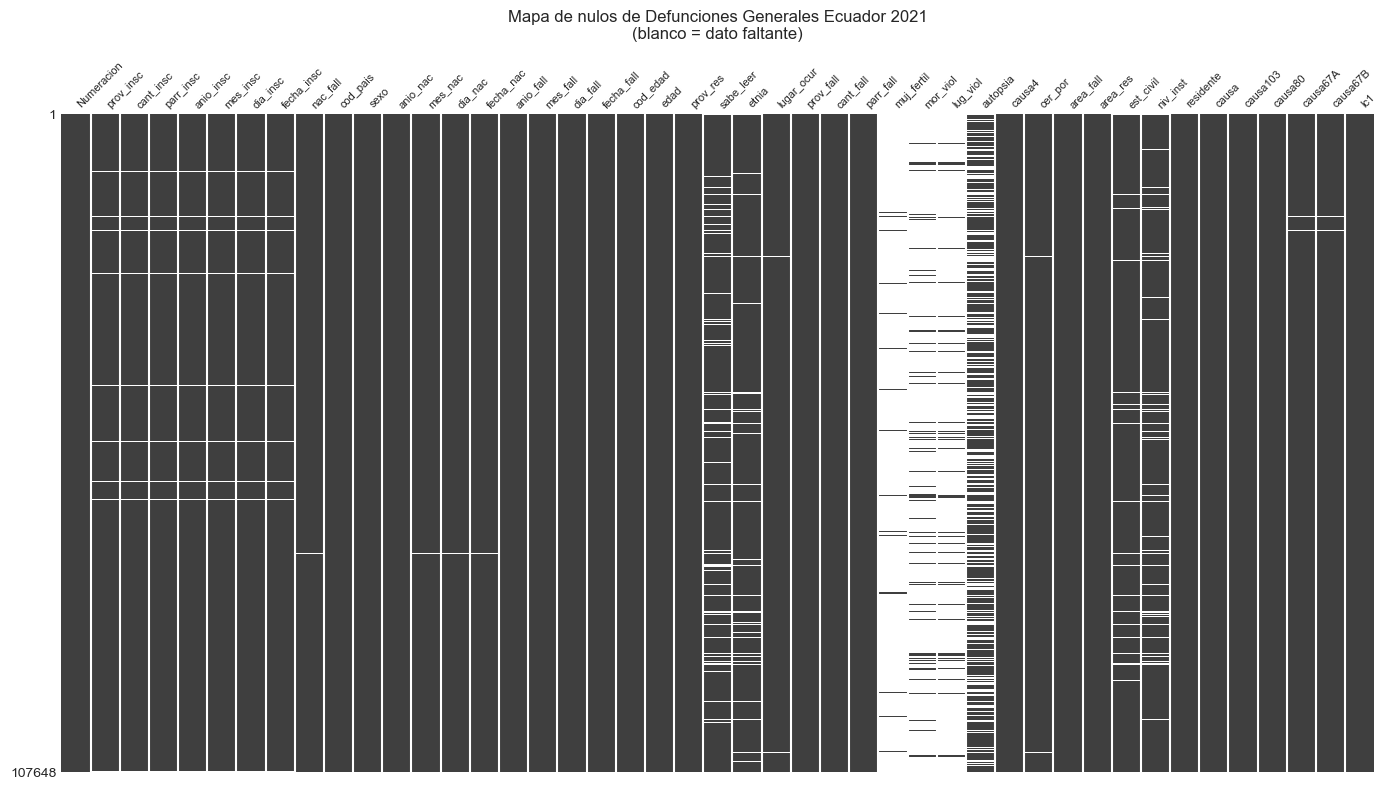

In [35]:
# Mapa de nulos con missingno
fig, ax = plt.subplots(figsize=(14, 8))
msno.matrix(df_temp, ax=ax, fontsize=8, sparkline=False)
ax.set_title('Mapa de nulos de Defunciones Generales Ecuador 2021\n(blanco = dato faltante)', 
             fontsize=12, pad=15)

plt.tight_layout()
plt.savefig('../reports/figures/01_mapa_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones de la auditoría

### Estado general del dataset
El dataset reportaba 0 valores nulos, pero la auditoría reveló alrededor de 
**370,000 celdas con datos faltantes disfrazados** en tres formas principales: espacios
en blanco, texto "Sin información" y fechas imposibles como `9999-99-99`.

### Problemas encontrados (9 en total)

| # | Problema | Severidad |
|---|---|---|
| 1 | Nulos disfrazados: espacios en blanco (~313,000 celdas) | Alta |
| 2 | Nulos disfrazados: "Sin información" (~56,000 celdas) | Alta |
| 3 | Nulos disfrazados: "No aplica" (382 celdas) | Baja |
| 4 | Fechas imposibles: `9999-99-99` (103 registros) | Media |
| 5 | Fechas parciales: `año-99-99` (98 registros) | Media |
| 6 | Tipos mixtos: columnas numéricas como texto (3 columnas) | Alta |
| 7 | Registros de años anteriores a 2021 (2,400) | Media |
| 8 | Código + descripción pegados en columnas de causa (6 columnas) | Media |
| 9 | 7 pares de registros duplicados (14 filas) | Baja |

### Nulos estructurales (no son errores)
Las columnas `muj_fertil`, `mor_viol` y `lug_viol` tienen >90% de nulos
porque solo aplican a subconjuntos específicos (mujeres fértiles, muertes
violentas). No son datos faltantes, son campos que no corresponden.

### Siguiente paso
En el Notebook 02 se construirá un pipeline de limpieza que resuelva cada problema
en orden de severidad, documentando cada decisión.
